Beyza Yıldız

# **TASK-1**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# defining the mlp model
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden1=250, hidden2=100, output_size=10, activation='relu'):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, output_size)
        self.activation = nn.ReLU() if activation == 'relu' else nn.Sigmoid()

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.fc3(x)
        return x

In [ ]:
# loading the data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

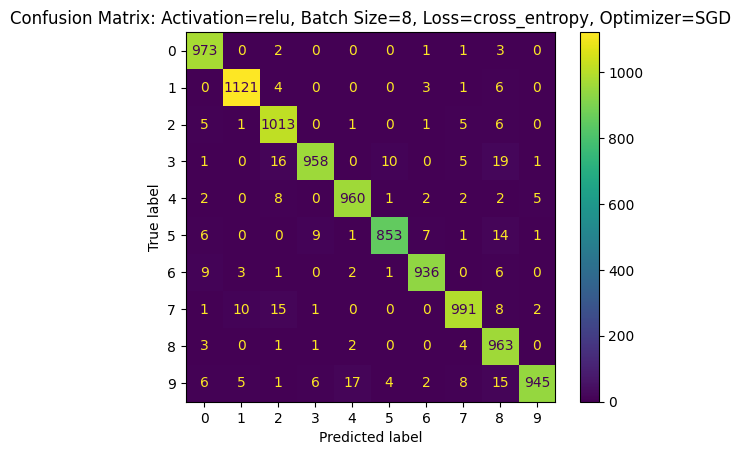

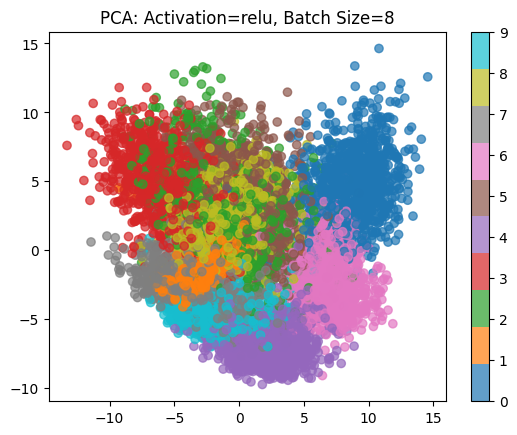

In [ ]:
def train_and_evaluate(activation, batch_size, loss_fn, optimizer_type):
    # Dataloaders
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # model, loss function, and optimizer implementation
    model = MLP(activation=activation).to(device)
    criterion = nn.CrossEntropyLoss() if loss_fn == 'cross_entropy' else nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01) if optimizer_type == 'SGD' else optim.Adam(model.parameters(), lr=0.01)

    # training loop part
    epochs = 5
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels) if loss_fn == 'cross_entropy' else criterion(outputs, nn.functional.one_hot(labels, num_classes=10).float())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # evaluation of the model
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    # confusion matrix creation
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
    disp.plot()
    plt.title(f'Confusion Matrix: Activation={activation}, Batch Size={batch_size}, Loss={loss_fn}, Optimizer={optimizer_type}')
    plt.show()

    # pca visualization before second hidden layer
    pca_data = []
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            x = images.view(images.size(0), -1)
            h1 = model.activation(model.fc1(x))
            h2 = model.activation(model.fc2(h1))
            pca_data.append(h2.cpu().numpy())
    pca_data = np.concatenate(pca_data)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(pca_data)

    plt.scatter(pca_result[:, 0], pca_result[:, 1], c=all_labels, cmap='tab10', alpha=0.7)
    plt.title(f'PCA: Activation={activation}, Batch Size={batch_size}')
    plt.colorbar()
    plt.show()


train_and_evaluate(activation='relu', batch_size=8, loss_fn='cross_entropy', optimizer_type='SGD')


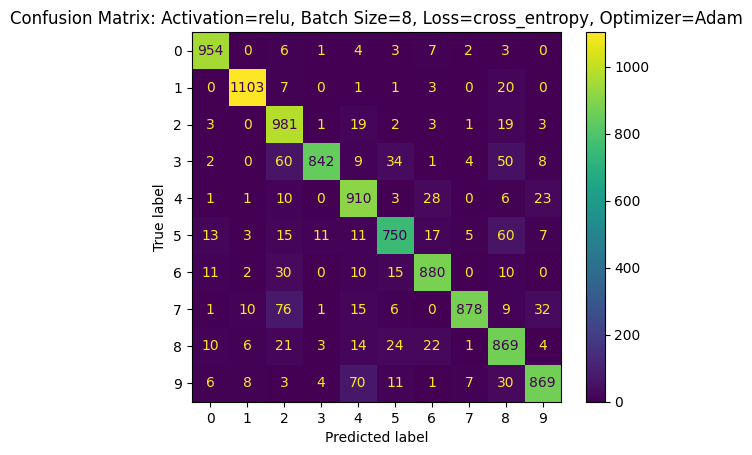

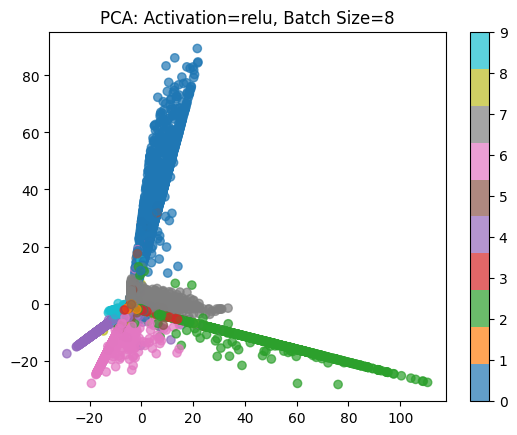

In [ ]:
train_and_evaluate(activation='relu', batch_size=8, loss_fn='cross_entropy', optimizer_type='Adam')

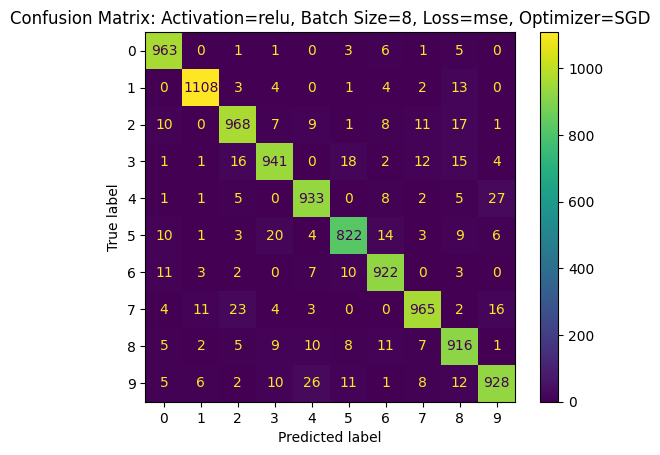

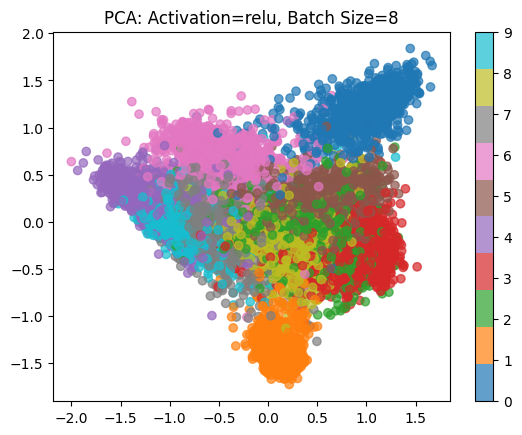

In [ ]:
train_and_evaluate(activation='relu', batch_size=8, loss_fn='mse', optimizer_type='SGD')

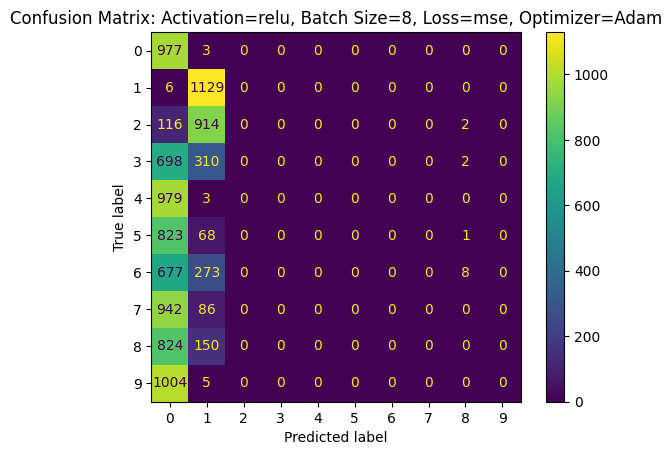

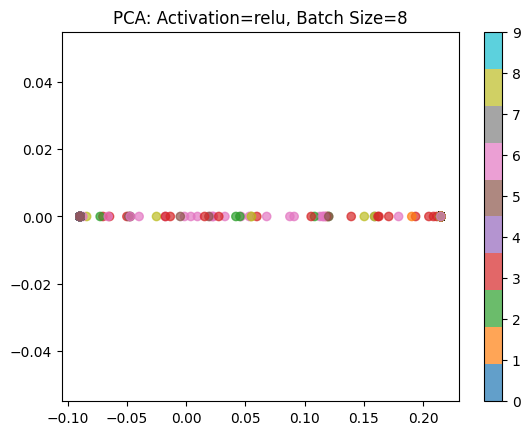

In [ ]:
train_and_evaluate(activation='relu', batch_size=8, loss_fn='mse', optimizer_type='Adam')

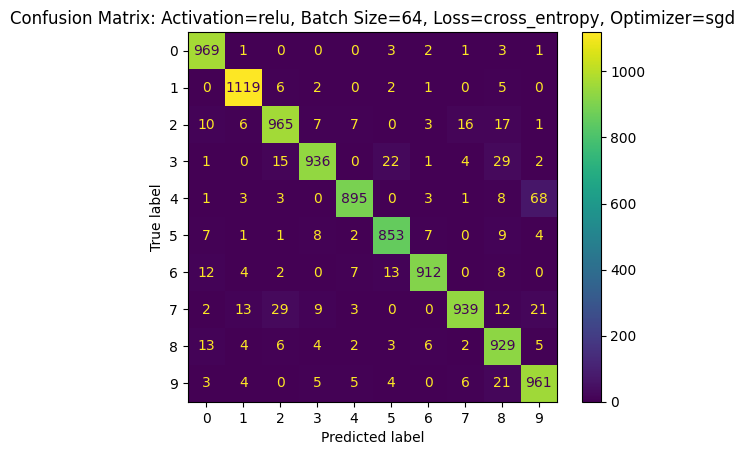

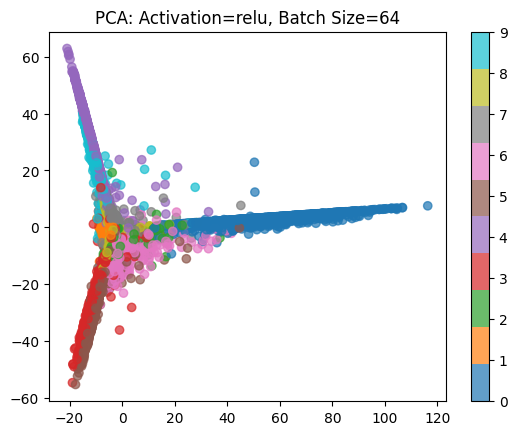

In [ ]:
train_and_evaluate(activation='relu', batch_size=64, loss_fn='cross_entropy', optimizer_type='sgd')

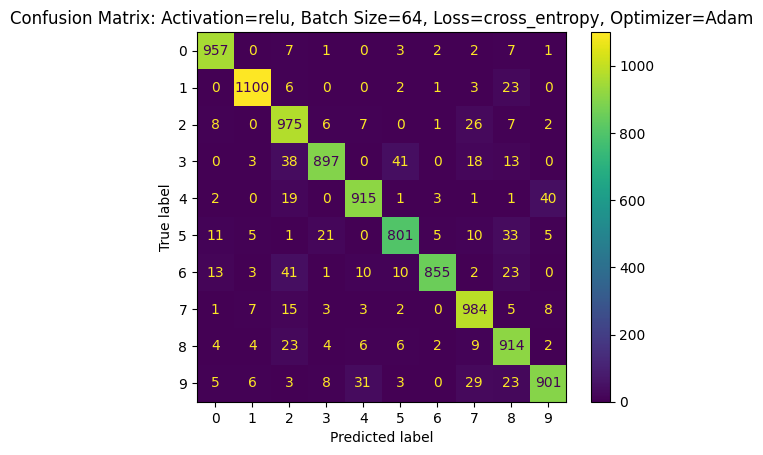

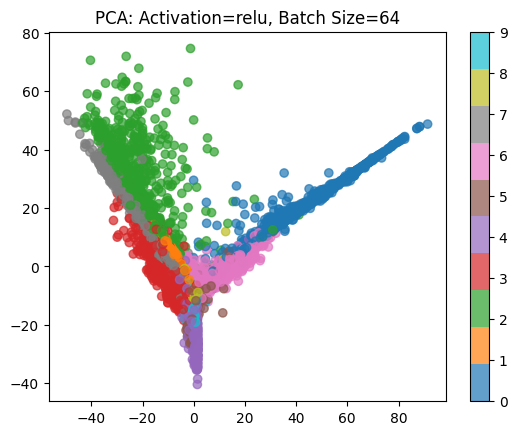

In [ ]:
train_and_evaluate(activation='relu', batch_size=64, loss_fn='cross_entropy', optimizer_type='Adam')

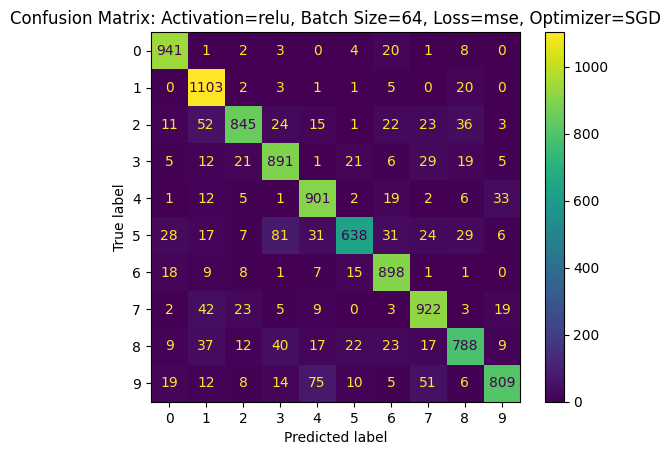

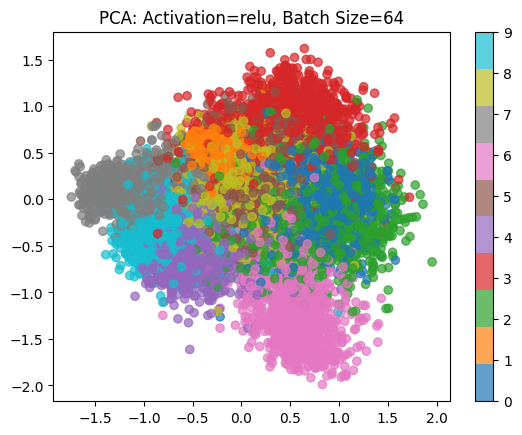

In [ ]:
train_and_evaluate(activation='relu', batch_size=64, loss_fn='mse', optimizer_type='SGD')

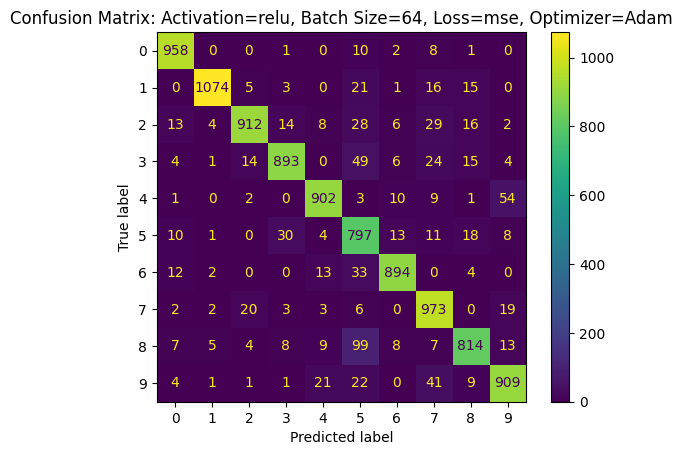

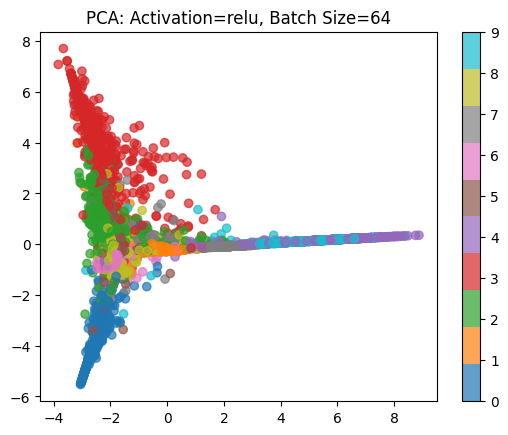

In [ ]:
train_and_evaluate(activation='relu', batch_size=64, loss_fn='mse', optimizer_type='Adam')

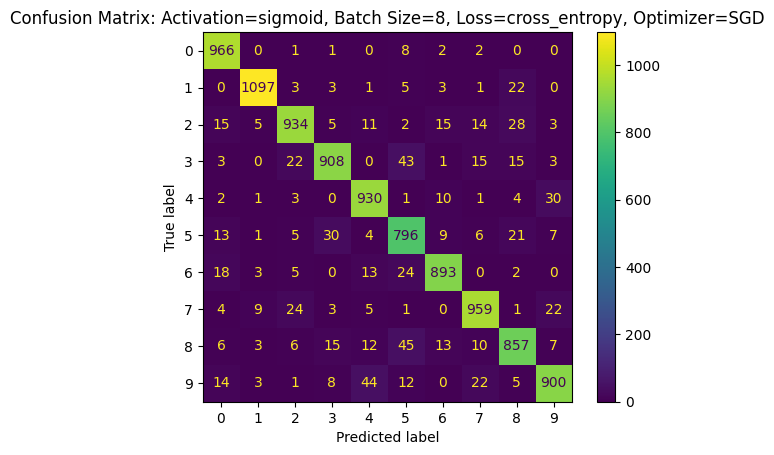

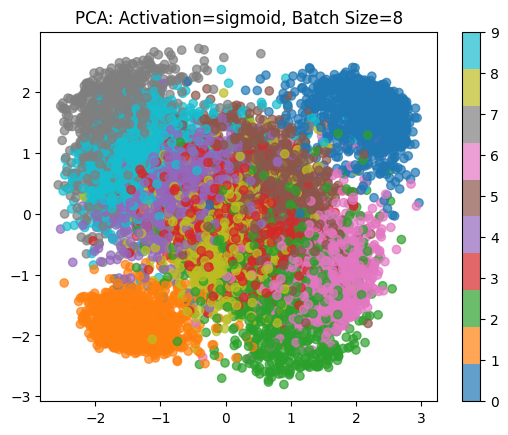

In [ ]:
train_and_evaluate(activation='sigmoid', batch_size=8, loss_fn='cross_entropy', optimizer_type='SGD')

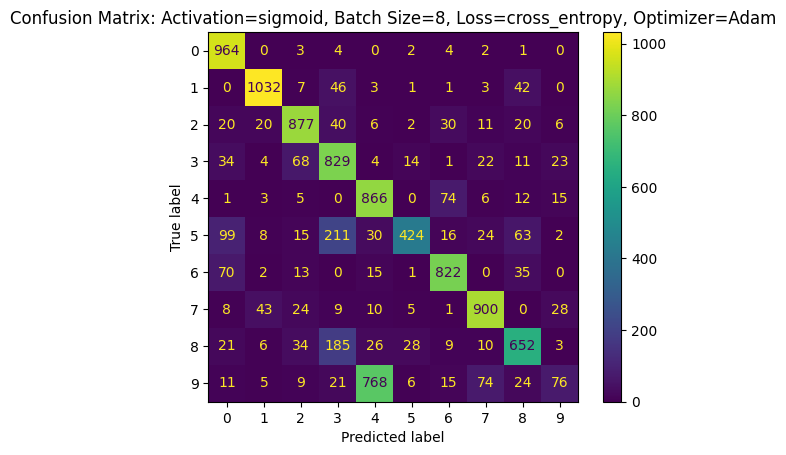

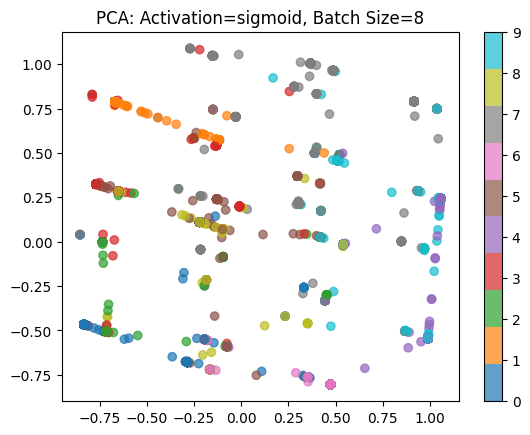

In [ ]:
train_and_evaluate(activation='sigmoid', batch_size=8, loss_fn='cross_entropy', optimizer_type='Adam')

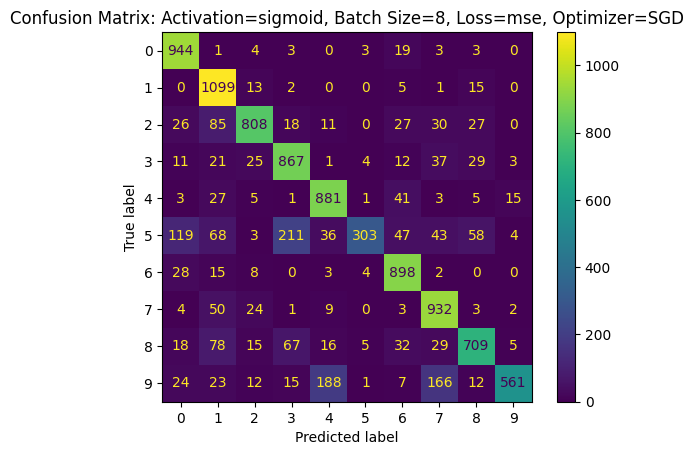

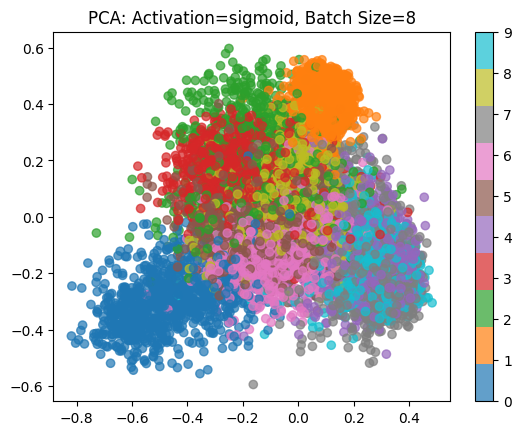

In [ ]:
train_and_evaluate(activation='sigmoid', batch_size=8, loss_fn='mse', optimizer_type='SGD')

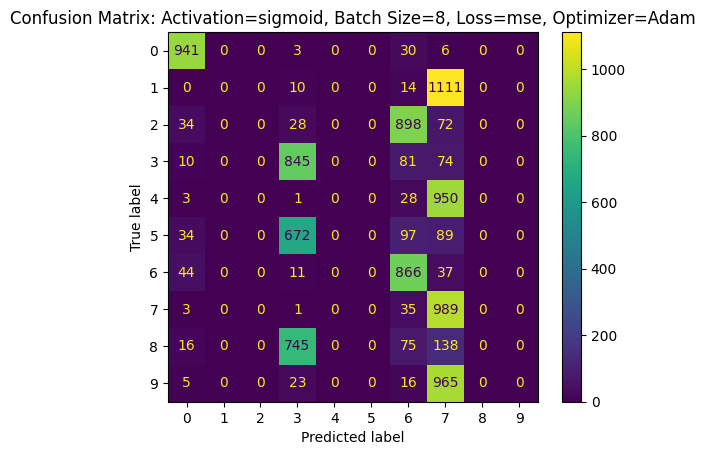

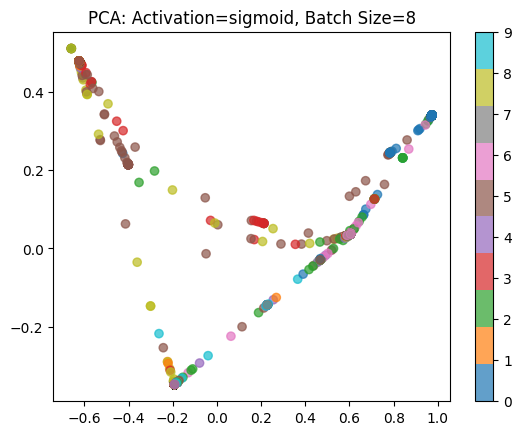

In [ ]:
train_and_evaluate(activation='sigmoid', batch_size=8, loss_fn='mse', optimizer_type='Adam')

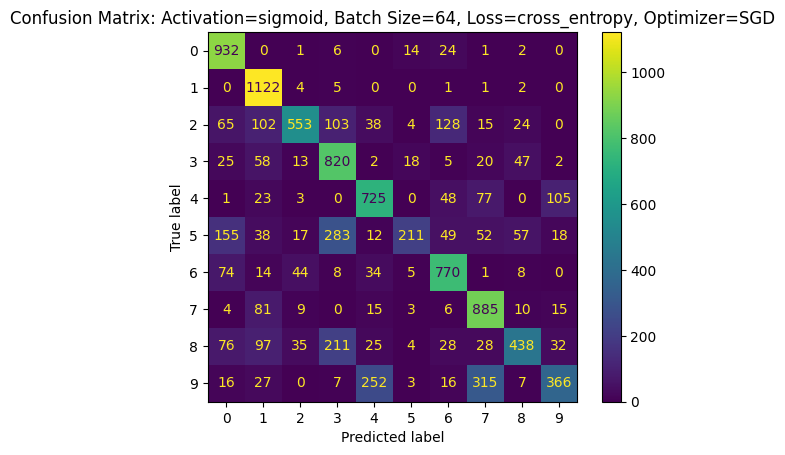

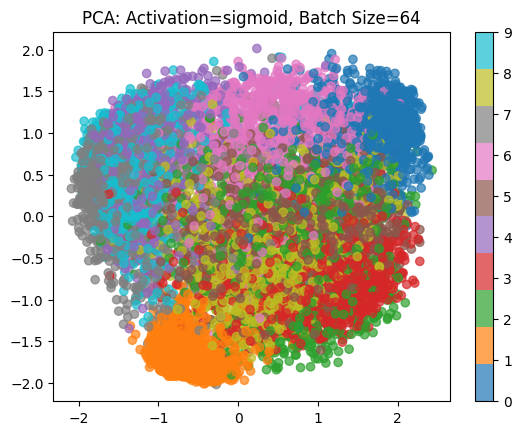

In [ ]:
train_and_evaluate(activation='sigmoid', batch_size=64, loss_fn='cross_entropy', optimizer_type='SGD')

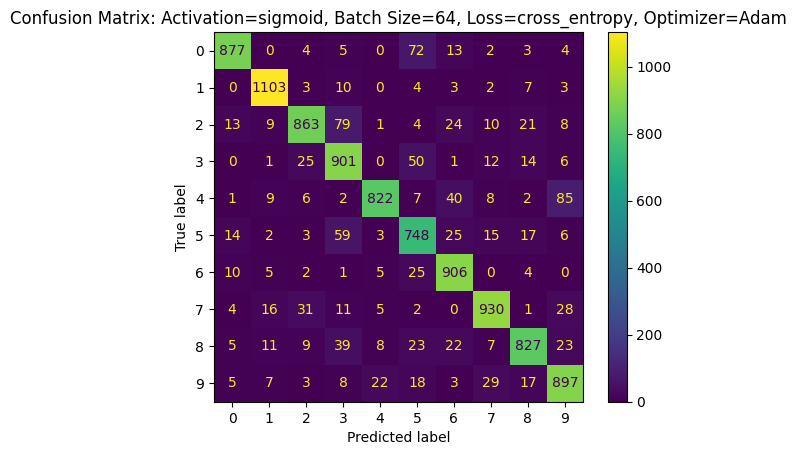

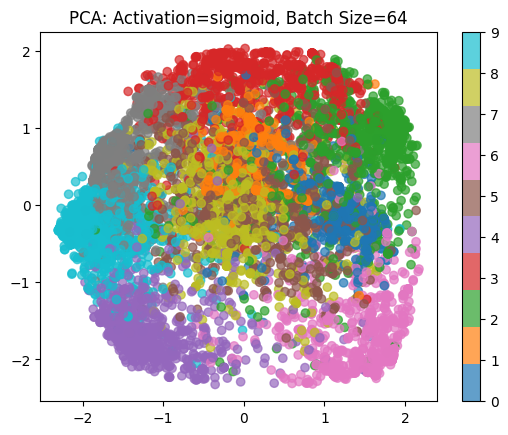

In [ ]:
train_and_evaluate(activation='sigmoid', batch_size=64, loss_fn='cross_entropy', optimizer_type='Adam')

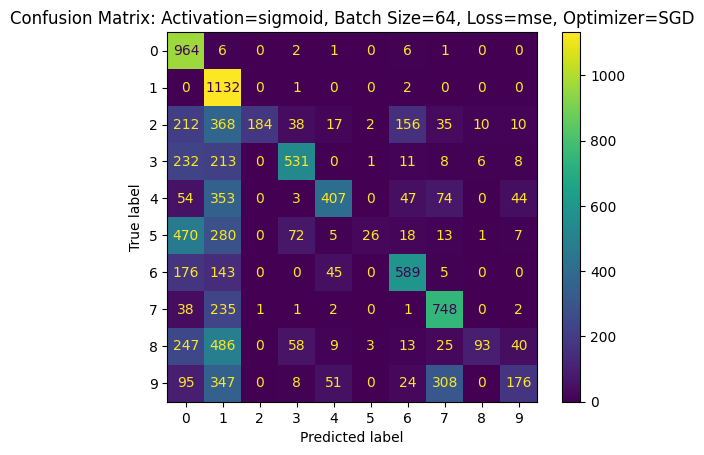

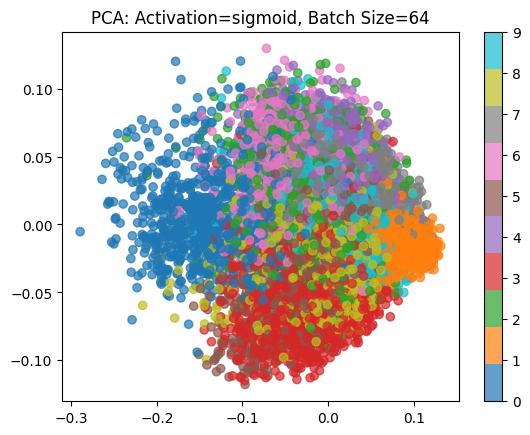

In [ ]:
train_and_evaluate(activation='sigmoid', batch_size=64, loss_fn='mse', optimizer_type='SGD')

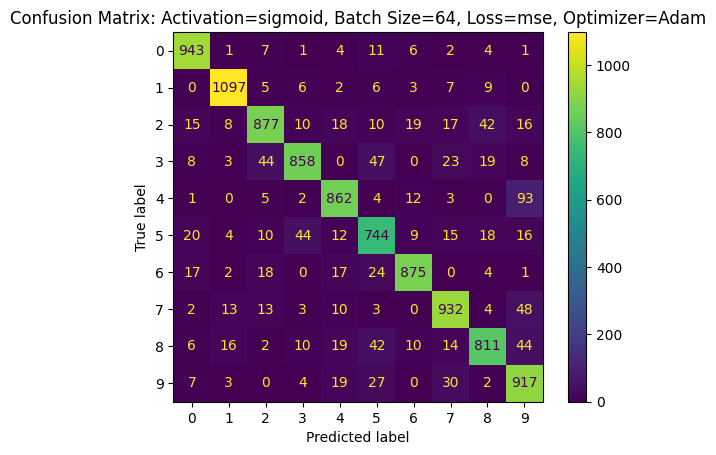

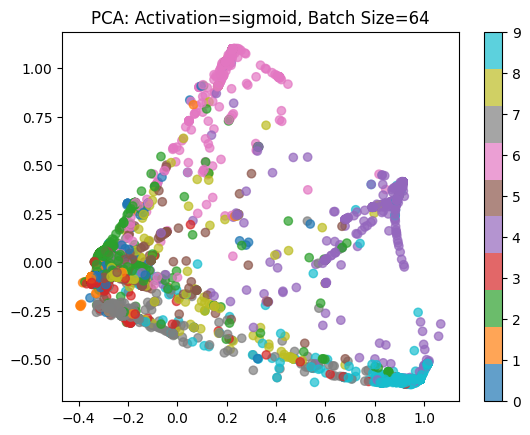

In [ ]:
train_and_evaluate(activation='sigmoid', batch_size=64, loss_fn='mse', optimizer_type='Adam')

# **TASK-2**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# CIFAR-10 data preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

100%|██████████| 170M/170M [00:11<00:00, 14.7MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


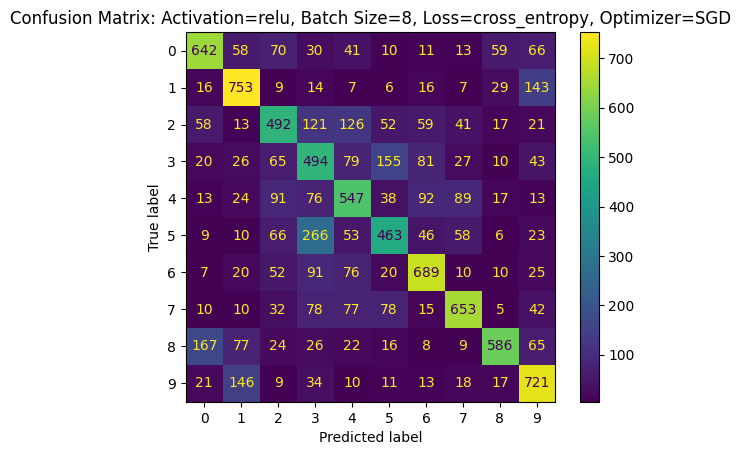

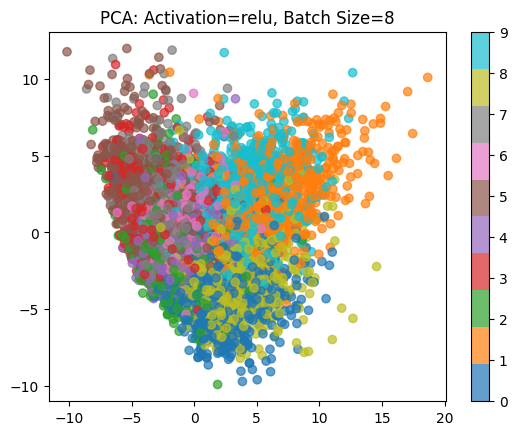

In [ ]:
# defining the lenet-5 model
class LeNet5(nn.Module):
    def __init__(self, activation='relu'):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        self.activation = nn.ReLU() if activation == 'relu' else nn.Sigmoid()

    def forward(self, x):
        x = self.activation(self.conv1(x))
        x = nn.MaxPool2d(2)(x)
        x = self.activation(self.conv2(x))
        x = nn.MaxPool2d(2)(x)
        x = x.view(x.size(0), -1)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.fc3(x)
        return x

def train_and_evaluate(activation, batch_size, loss_fn, optimizer_type):
    # data loader part
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Model, loss, optimizer
    model = LeNet5(activation=activation).to(device)
    criterion = nn.CrossEntropyLoss() if loss_fn == 'cross_entropy' else nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01) if optimizer_type == 'SGD' else optim.Adam(model.parameters(), lr=0.01)

    # training loop part
    epochs = 5
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels) if loss_fn == 'cross_entropy' else criterion(outputs, nn.functional.one_hot(labels, num_classes=10).float())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # evaluation of the model
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    # confusion matrix creation
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
    disp.plot()
    plt.title(f'Confusion Matrix: Activation={activation}, Batch Size={batch_size}, Loss={loss_fn}, Optimizer={optimizer_type}')
    plt.show()

    # pca visualization before second-to-last layer
    pca_data = []
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            x = model.activation(model.conv1(images))
            x = nn.MaxPool2d(2)(x)
            x = model.activation(model.conv2(x))
            x = nn.MaxPool2d(2)(x)
            x = x.view(x.size(0), -1)
            x = model.activation(model.fc1(x))
            pca_data.append(x.cpu().numpy())
    pca_data = np.concatenate(pca_data)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(pca_data)

    plt.scatter(pca_result[:, 0], pca_result[:, 1], c=all_labels, cmap='tab10', alpha=0.7)
    plt.title(f'PCA: Activation={activation}, Batch Size={batch_size}')
    plt.colorbar()
    plt.show()

train_and_evaluate(activation='relu', batch_size=8, loss_fn='cross_entropy', optimizer_type='SGD')

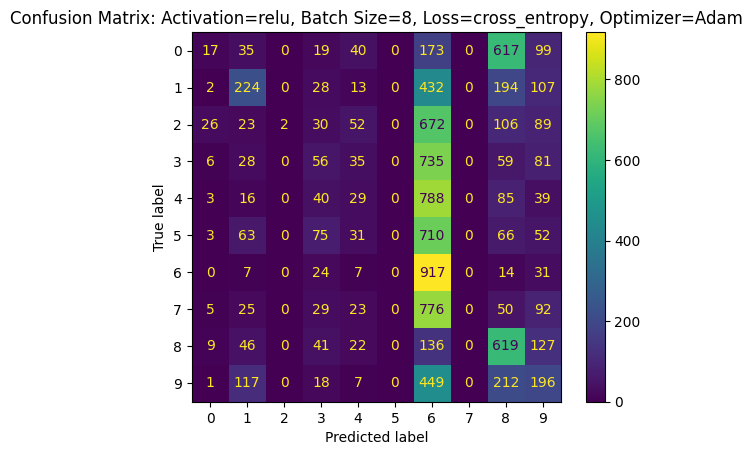

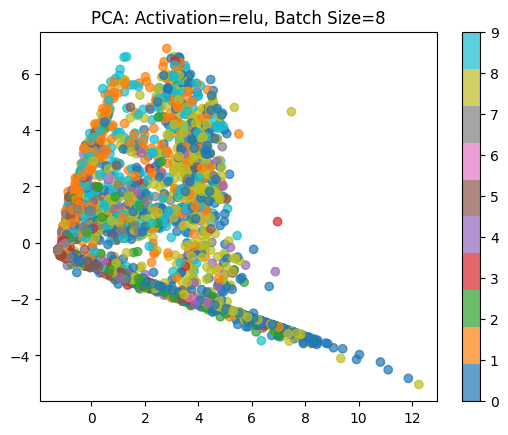

In [ ]:
train_and_evaluate(activation='relu', batch_size=8, loss_fn='cross_entropy', optimizer_type='Adam')

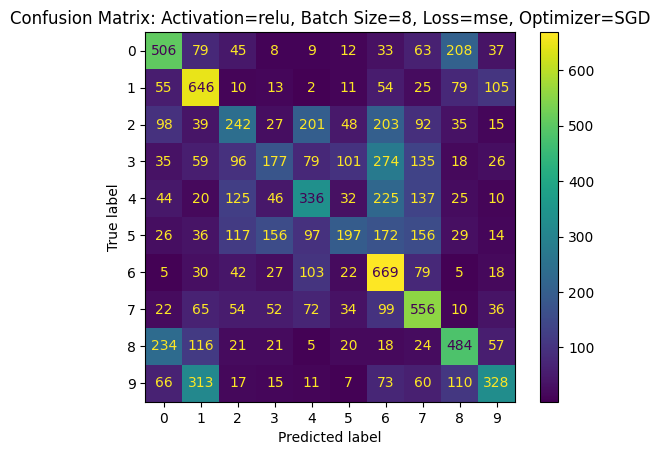

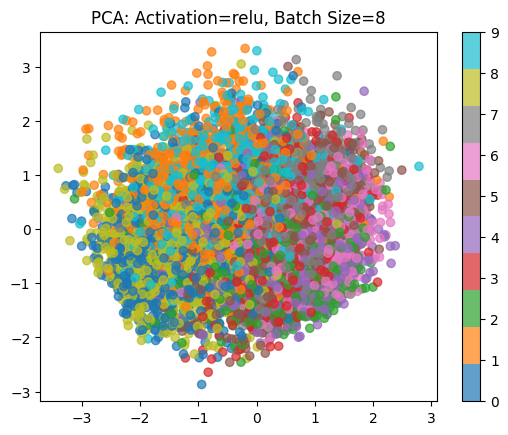

In [ ]:
train_and_evaluate(activation='relu', batch_size=8, loss_fn='mse', optimizer_type='SGD')

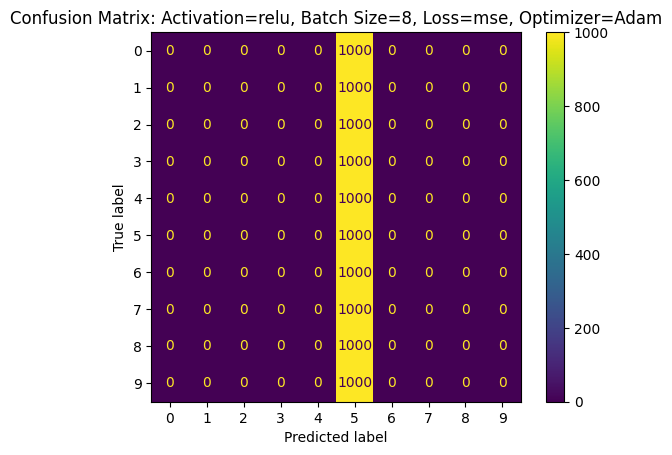

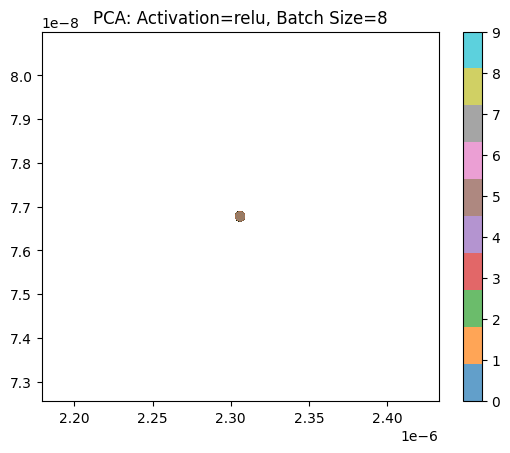

In [ ]:
train_and_evaluate(activation='relu', batch_size=8, loss_fn='mse', optimizer_type='Adam')

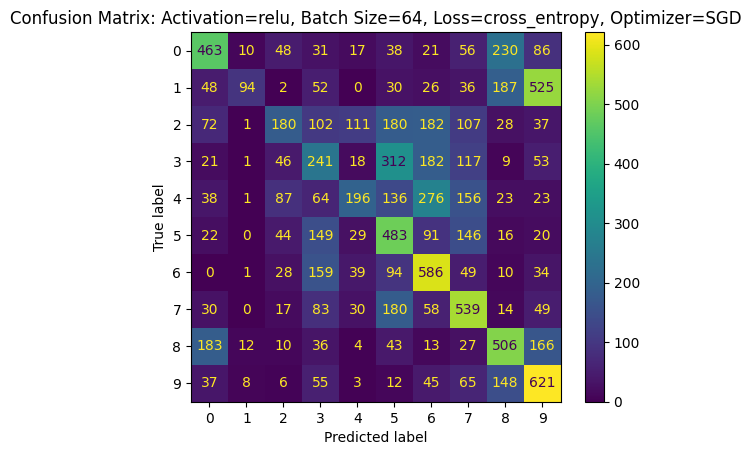

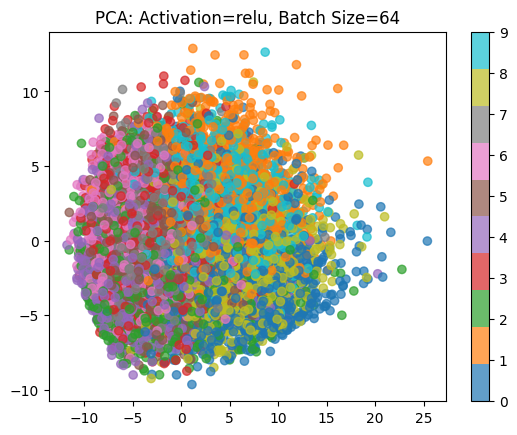

In [ ]:
train_and_evaluate(activation='relu', batch_size=64, loss_fn='cross_entropy', optimizer_type='SGD')

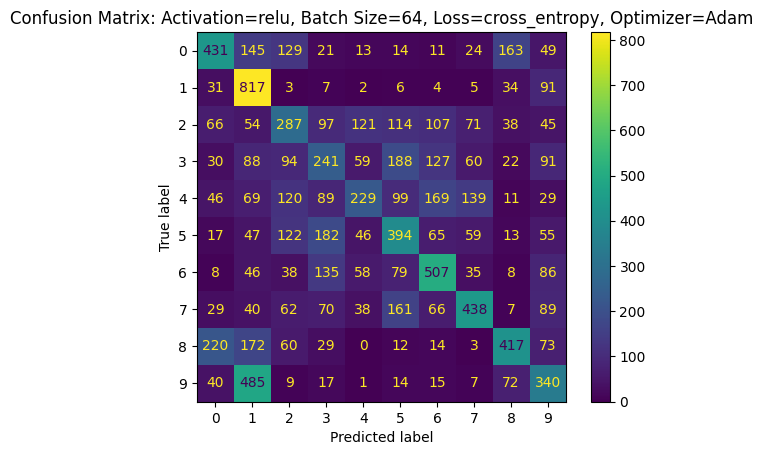

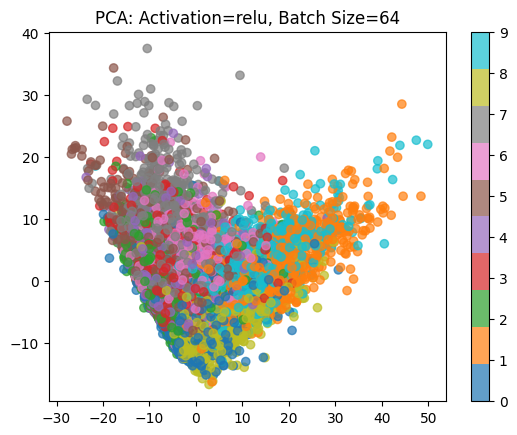

In [ ]:
train_and_evaluate(activation='relu', batch_size=64, loss_fn='cross_entropy', optimizer_type='Adam')

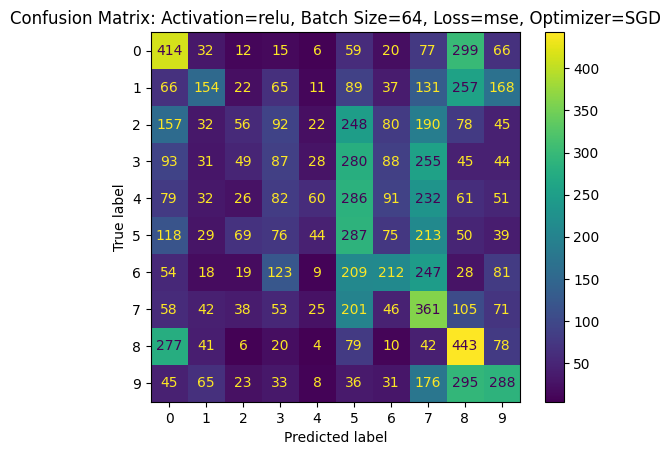

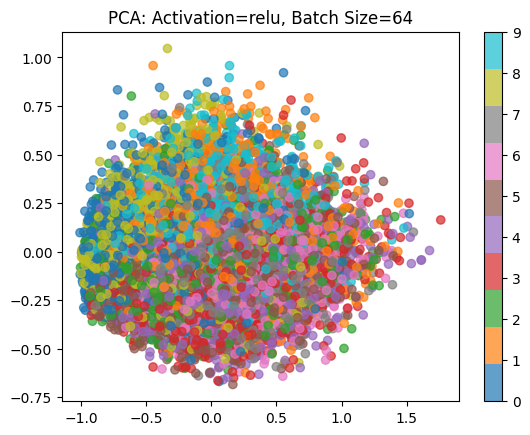

In [ ]:
train_and_evaluate(activation='relu', batch_size=64, loss_fn='mse', optimizer_type='SGD')

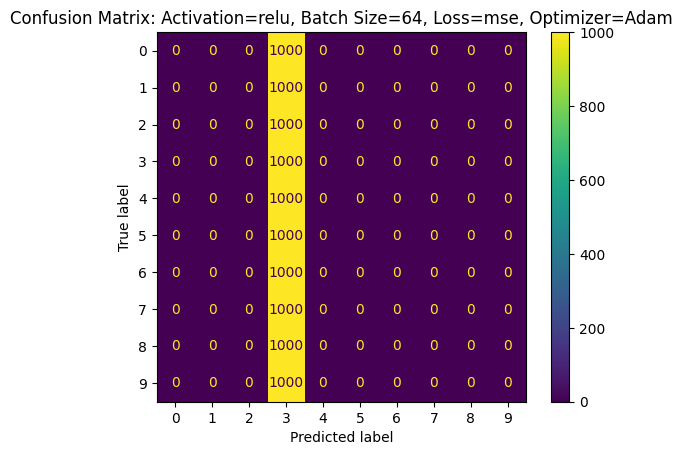

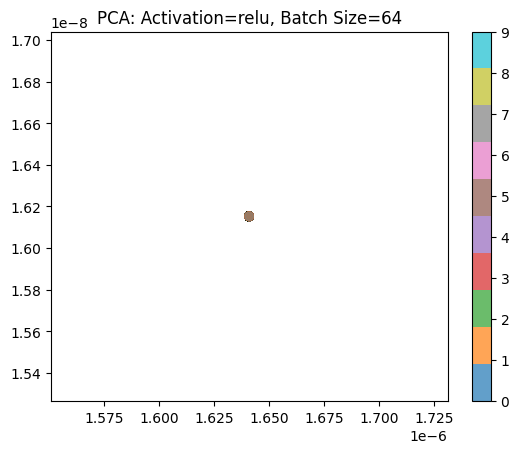

In [ ]:
train_and_evaluate(activation='relu', batch_size=64, loss_fn='mse', optimizer_type='Adam')

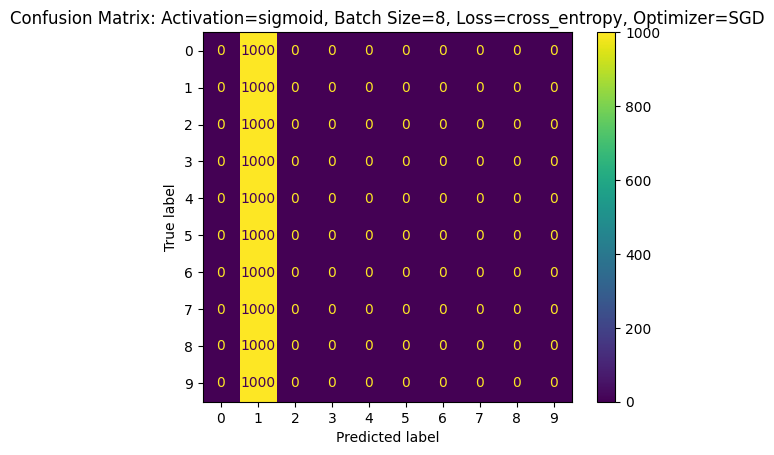

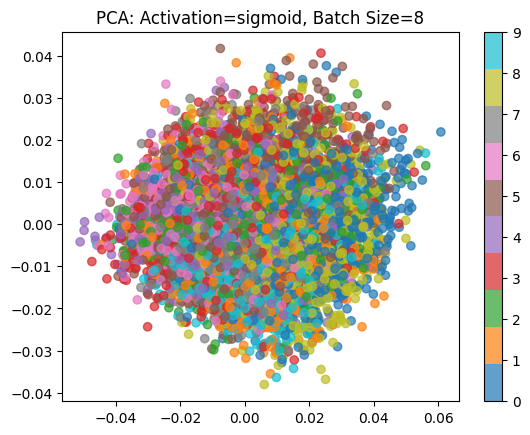

In [ ]:
train_and_evaluate(activation='sigmoid', batch_size=8, loss_fn='cross_entropy', optimizer_type='SGD')

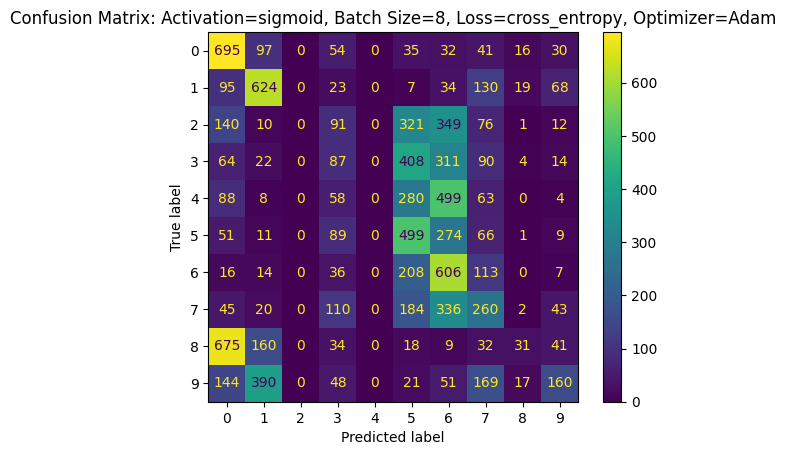

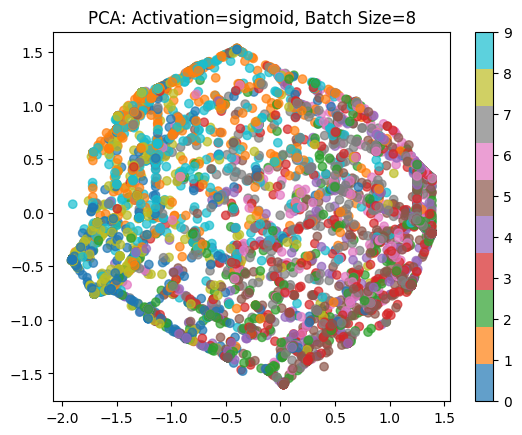

In [ ]:
train_and_evaluate(activation='sigmoid', batch_size=8, loss_fn='cross_entropy', optimizer_type='Adam')

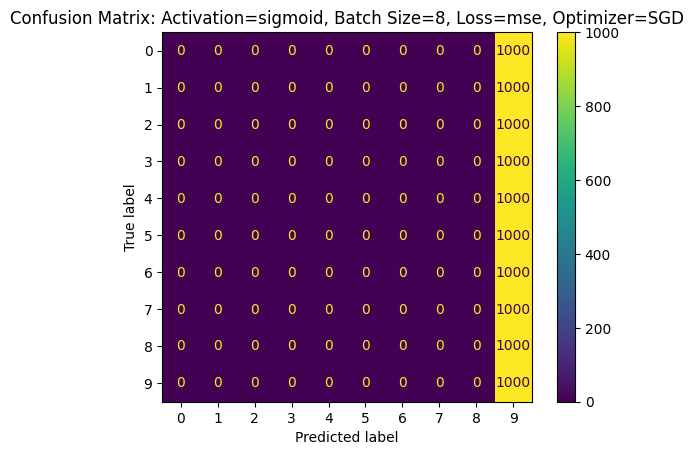

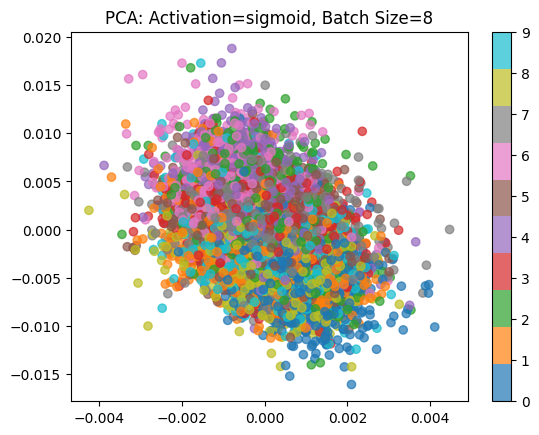

In [ ]:
train_and_evaluate(activation='sigmoid', batch_size=8, loss_fn='mse', optimizer_type='SGD')

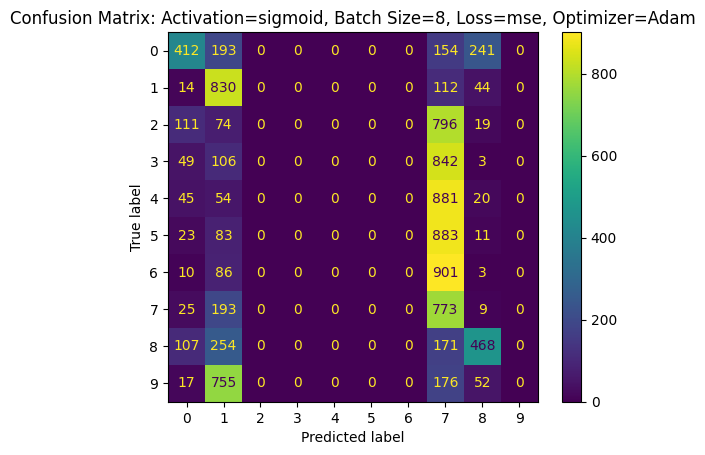

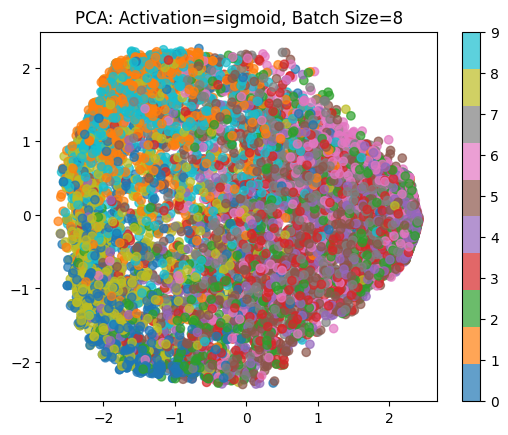

In [ ]:
train_and_evaluate(activation='sigmoid', batch_size=8, loss_fn='mse', optimizer_type='Adam')

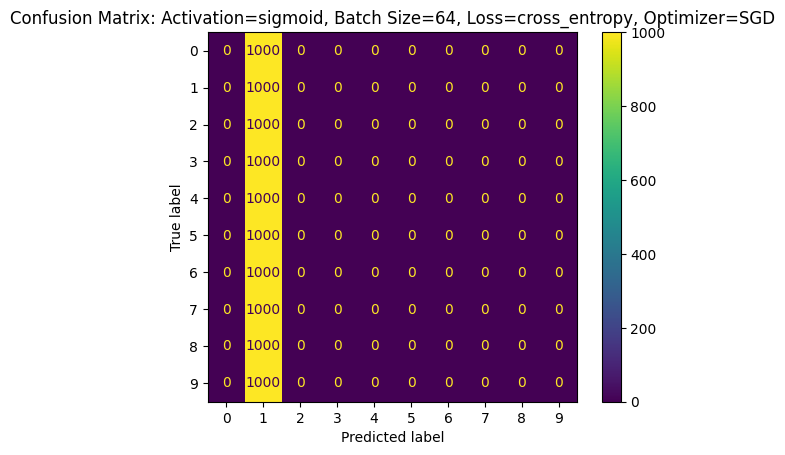

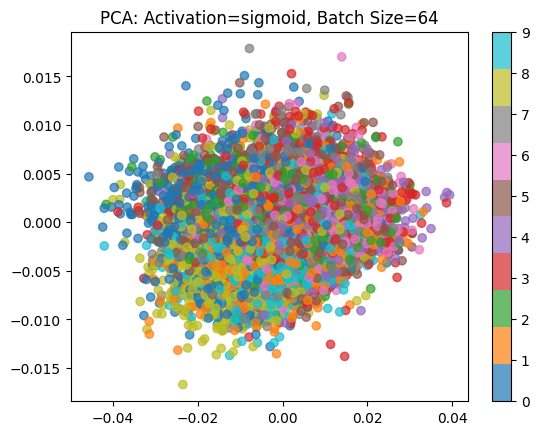

In [ ]:
train_and_evaluate(activation='sigmoid', batch_size=64, loss_fn='cross_entropy', optimizer_type='SGD')

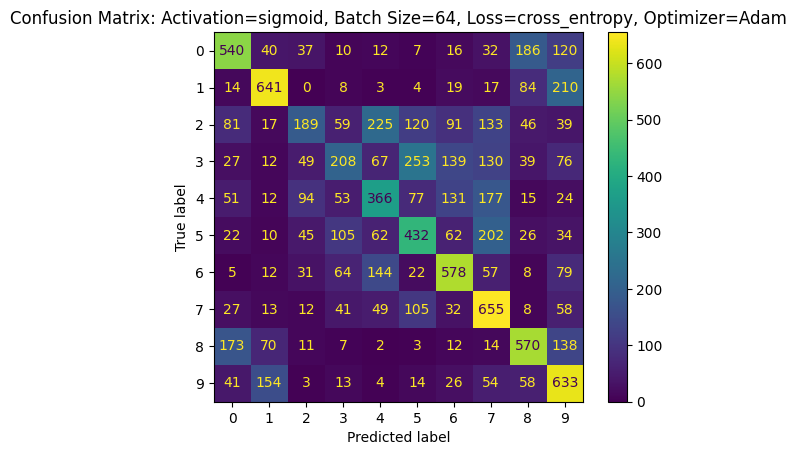

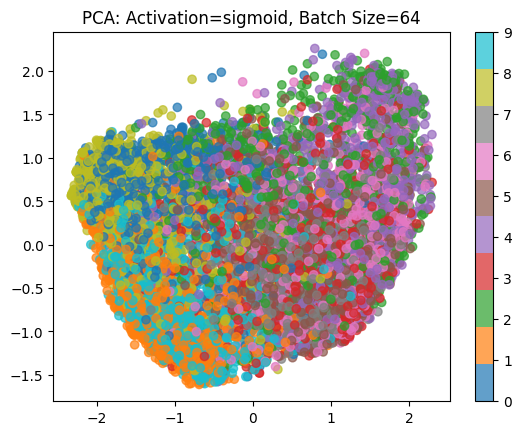

In [ ]:
train_and_evaluate(activation='sigmoid', batch_size=64, loss_fn='cross_entropy', optimizer_type='Adam')

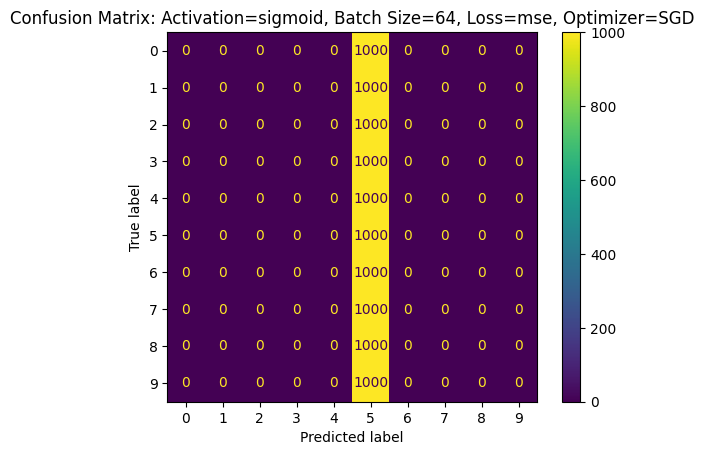

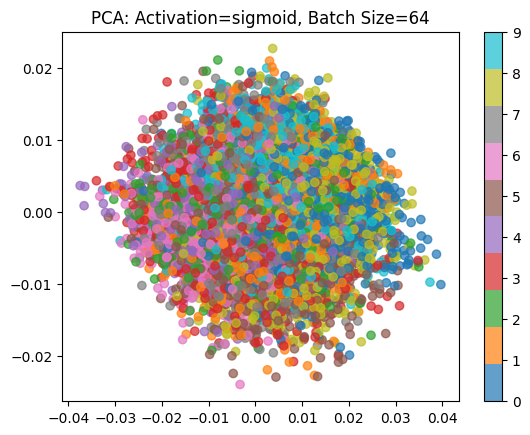

In [ ]:
train_and_evaluate(activation='sigmoid', batch_size=64, loss_fn='mse', optimizer_type='SGD')

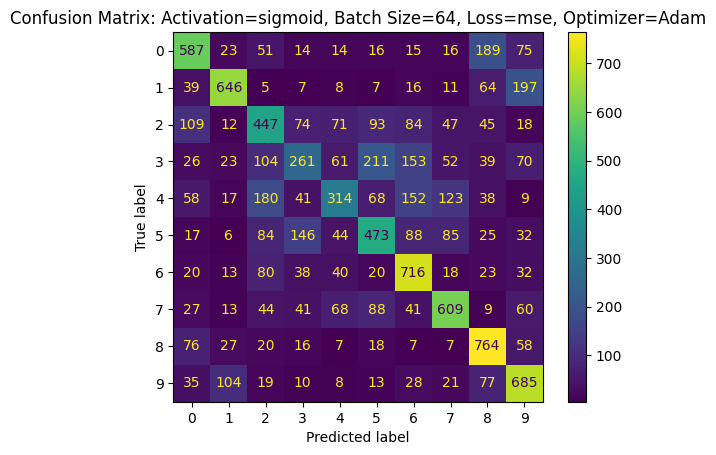

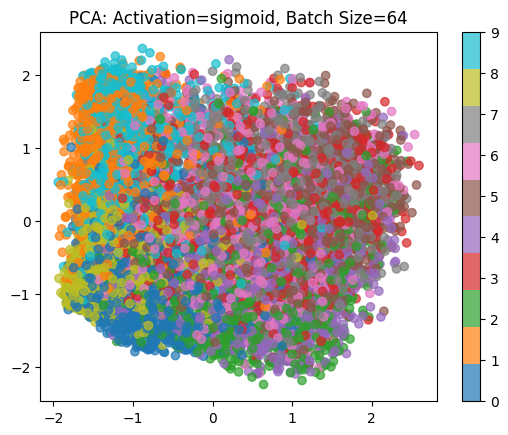

In [ ]:
train_and_evaluate(activation='sigmoid', batch_size=64, loss_fn='mse', optimizer_type='Adam')